#Project 9 : Optimizer Comparison to the Neural Network

1. Import Libraries and iris

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset shape:", X.shape)
print("Number of classes:", len(np.unique(y)))
print("Class names:", iris.target_names)

Dataset shape: (150, 4)
Number of classes: 3
Class names: ['setosa' 'versicolor' 'virginica']


2. Split and Standardize the Data

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of features:", X_train.shape[1])

Training samples: 120
Testing samples: 30
Number of features: 4


3. Build the Neural Network

In [3]:
def build_model(optimizer):
    model = Sequential([
        Dense(16, activation='relu', input_shape=(4,)),
        Dense(8, activation='relu'),
        Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


print("Neural network architecture ready.")

Neural network architecture ready.


4. Train thr Neural Network using SGD

In [4]:
# Create model with SGD optimizer
sgd_optimizer = SGD(learning_rate=0.01)

sgd_model = build_model(sgd_optimizer)

# Train the model
sgd_history = sgd_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 286ms/step - accuracy: 0.4375 - loss: 1.0904 - val_accuracy: 0.5417 - val_loss: 1.0848
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4375 - loss: 1.0464 - val_accuracy: 0.5000 - val_loss: 1.0446
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5625 - loss: 1.0082 - val_accuracy: 0.5833 - val_loss: 1.0080
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5833 - loss: 0.9736 - val_accuracy: 0.6667 - val_loss: 0.9771
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6667 - loss: 0.9426 - val_accuracy: 0.7500 - val_loss: 0.9491
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7396 - loss: 0.9143 - val_accuracy: 0.7500 - val_loss: 0.9229
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7812 - loss: 0.8878 - val_accuracy: 0.7500 - val_loss: 0.8984
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8229 - loss: 0.8630 - val_accuracy: 0.7500 - val_loss: 0.8752
Epoch 9/50

5. Train the Nueral Network with ADAM

In [5]:
# Create model with Adam optimizer
adam_optimizer = Adam(learning_rate=0.001)

adam_model = build_model(adam_optimizer)

# Train the model
adam_history = adam_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.3125 - loss: 1.1219 - val_accuracy: 0.4583 - val_loss: 1.1023
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4062 - loss: 1.1072 - val_accuracy: 0.5833 - val_loss: 1.0908
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5000 - loss: 1.0930 - val_accuracy: 0.5833 - val_loss: 1.0773
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5833 - loss: 1.0781 - val_accuracy: 0.6667 - val_loss: 1.0631
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6042 - loss: 1.0625 - val_accuracy: 0.6667 - val_loss: 1.0463
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6250 - loss: 1.0468 - val_accuracy: 0.6667 - val_loss: 1.0282
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6250 - loss: 1.0294 - val_accuracy: 0.6667 - val_loss: 1.0102
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6771 - loss: 1.0122 - val_accuracy: 0.7500 - val_loss: 0.9906


6. Evaluate SGD v/s ADAM

In [6]:
sgd_loss, sgd_accuracy = sgd_model.evaluate(
    X_test, y_test, verbose=0
)

adam_loss, adam_accuracy = adam_model.evaluate(
    X_test, y_test, verbose=0
)

print("SGD Results")
print("Test Loss:", round(sgd_loss, 4))
print("Test Accuracy:", round(sgd_accuracy * 100, 2), "%")

print("\nAdam Results")
print("Test Loss:", round(adam_loss, 4))
print("Test Accuracy:", round(adam_accuracy * 100, 2), "%")

SGD Results
Test Loss: 0.4278
Test Accuracy: 80.0 %

Adam Results
Test Loss: 0.327
Test Accuracy: 86.67 %


7. Classification Report

In [7]:
# Predictions from SGD
sgd_predictions = np.argmax(
    sgd_model.predict(X_test, verbose=0),
    axis=1
)

# Predictions from Adam
adam_predictions = np.argmax(
    adam_model.predict(X_test, verbose=0),
    axis=1
)

print("=" * 50)
print("SGD CLASSIFICATION REPORT")
print("=" * 50)

print(classification_report(
    y_test,
    sgd_predictions,
    target_names=iris.target_names
))

print("=" * 50)
print("ADAM CLASSIFICATION REPORT")
print("=" * 50)

print(classification_report(
    y_test,
    adam_predictions,
    target_names=iris.target_names
))

SGD CLASSIFICATION REPORT
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.40      0.57        10
   virginica       0.62      1.00      0.77        10

    accuracy                           0.80        30
   macro avg       0.88      0.80      0.78        30
weighted avg       0.88      0.80      0.78        30

ADAM CLASSIFICATION REPORT
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.88      0.70      0.78        10
   virginica       0.75      0.90      0.82        10

    accuracy                           0.87        30
   macro avg       0.88      0.87      0.87        30
weighted avg       0.88      0.87      0.87        30



8. Compare the Training Loss

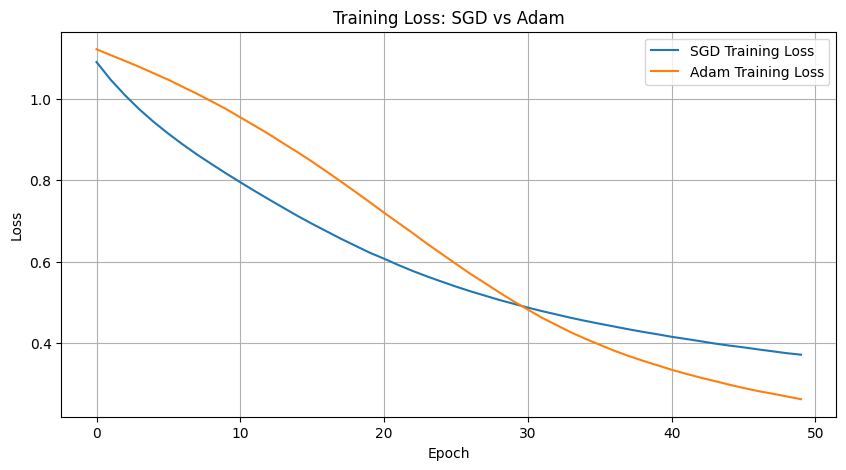

In [8]:

plt.figure(figsize=(10, 5))

plt.plot(
    sgd_history.history['loss'],
    label='SGD Training Loss'
)

plt.plot(
    adam_history.history['loss'],
    label='Adam Training Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss: SGD vs Adam')
plt.legend()
plt.grid(True)

plt.show()

9. Comparing Training Accuracy

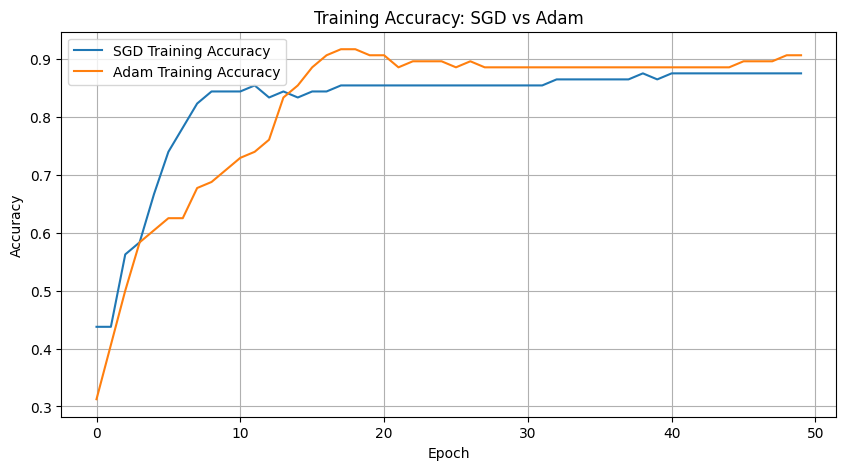

In [9]:
plt.figure(figsize=(10, 5))

plt.plot(
    sgd_history.history['accuracy'],
    label='SGD Training Accuracy'
)

plt.plot(
    adam_history.history['accuracy'],
    label='Adam Training Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy: SGD vs Adam')
plt.legend()
plt.grid(True)

plt.show()

10. Final Comparison

In [10]:
comparison = pd.DataFrame({
    'Optimizer': ['SGD', 'Adam'],
    'Learning Rate': [0.01, 0.001],
    'Test Loss': [sgd_loss, adam_loss],
    'Test Accuracy (%)': [
        sgd_accuracy * 100,
        adam_accuracy * 100
    ]
})

comparison['Test Loss'] = comparison['Test Loss'].round(4)
comparison['Test Accuracy (%)'] = comparison['Test Accuracy (%)'].round(2)

print(comparison)

  Optimizer  Learning Rate  Test Loss  Test Accuracy (%)
0       SGD          0.010     0.4278              80.00
1      Adam          0.001     0.3270              86.67


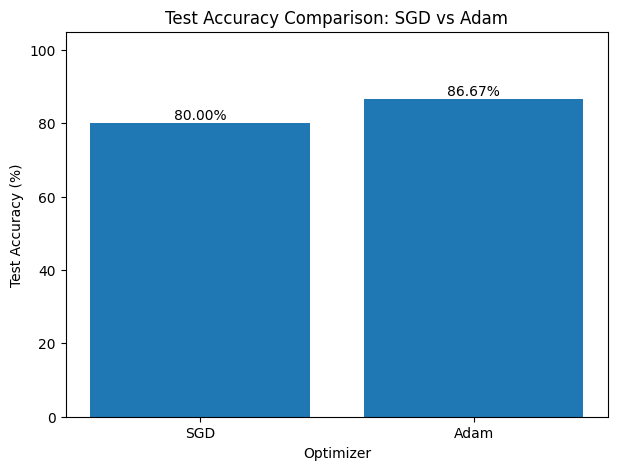

In [11]:
optimizers = ['SGD', 'Adam']
accuracies = [
    sgd_accuracy * 100,
    adam_accuracy * 100
]

plt.figure(figsize=(7, 5))

bars = plt.bar(optimizers, accuracies)

plt.xlabel('Optimizer')
plt.ylabel('Test Accuracy (%)')
plt.title('Test Accuracy Comparison: SGD vs Adam')
plt.ylim(0, 105)

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{accuracy:.2f}%',
        ha='center'
    )

plt.show()

#FINAL RESULT

In [12]:
print("=" * 55)
print("FINAL RESULT")
print("=" * 55)

print(f"SGD  Test Accuracy : {sgd_accuracy * 100:.2f}%")
print(f"Adam Test Accuracy : {adam_accuracy * 100:.2f}%")

print(f"\nSGD  Test Loss     : {sgd_loss:.4f}")
print(f"Adam Test Loss     : {adam_loss:.4f}")

if adam_accuracy > sgd_accuracy:
    print("\nAdam achieved higher test accuracy in this experiment.")
elif sgd_accuracy > adam_accuracy:
    print("\nSGD achieved higher test accuracy in this experiment.")
else:
    print("\nBoth optimizers achieved the same test accuracy.")

FINAL RESULT
SGD  Test Accuracy : 80.00%
Adam Test Accuracy : 86.67%

SGD  Test Loss     : 0.4278
Adam Test Loss     : 0.3270

Adam achieved higher test accuracy in this experiment.
